# Proyecto: Análisis Estadístico de Spotify

**Título:** Análisis estadístico de pistas de Spotify (2015-2025)

**Autores:** Fabian A Almeida Martinez, Diego Hernandez Rodriguez.        
**Curso:** Estadística 2025-2026

**Resumen ejecutivo:**
En este proyecto analizamos un conjunto de datos de canciones de Spotify (2015-2025) para investigar qué características acústicas y meta-datos se relacionan con la popularidad de las pistas, si existen diferencias entre géneros y cómo se pueden agrupar las canciones según su perfil sonoro. Se presentan procedimientos de EDA, limpieza de datos, pruebas estadísticas, regresión, PCA, clustering y clasificación, con interpretación clara y recomendaciones para la presentación oral.

## Índice

1. Definición del problema y preguntas de investigación
2. Carga y descripción de los datos
3. Análisis Exploratorio de Datos (EDA)
4. Preparación de Datos
5. Aplicación de técnicas estadísticas (Pruebas, Regresión, PCA, Clustering, Clasificación)
6. Resultados y Conclusiones
7. Apéndice y reproducibilidad

In [1]:
# Instalación de paquetes necesarios (se ejecuta una sola vez si hace falta)
%pip install --quiet pandas numpy matplotlib seaborn scikit-learn statsmodels scipy plotly python-pptx

# Importar librerías
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import time

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, silhouette_score

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Opciones estéticas
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

# Helper: ejecutar y medir tiempo con mensajes amigables
def run_with_time(label, func, *args, **kwargs):
    print(f"→ {label}: empezando (puede tardar unos segundos)...")
    t0 = time.time()
    res = func(*args, **kwargs)
    print(f"→ {label}: terminado en {time.time() - t0:.1f}s")
    return res


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 1. Definición del problema y contexto

**Tema elegido:** Música popular — análisis de pistas de Spotify (2015-2025).  

**Justificación:** La industria musical se basa cada vez más en datos de streaming para tomar decisiones sobre promoción, playlisting y estrategia de artistas. Entender qué características acústicas y meta-datos se asocian con la popularidad puede ayudar a explicar patrones de éxito y sugerir estrategias para artistas y sellos.

**Objetivo general:** Analizar la relación entre las características de las canciones y su popularidad, identificar diferencias entre géneros y extraer agrupaciones naturales de pistas basadas en perfiles sonoros.

## 2. Formulación de preguntas de investigación

1. ¿Qué características acústicas (danceability, energy, loudness, tempo, instrumentalness, etc.) están más asociadas con la `popularity` de una canción?
2. ¿Existen diferencias significativas en la `popularity` entre géneros musicales?
3. ¿Es posible agrupar las canciones en clusters con perfiles acústicos distintos y qué características definen cada cluster?

Estas preguntas permiten aplicar pruebas de hipótesis, regresión, PCA y clustering, además de métodos de clasificación si se desea predecir clases (por ejemplo, `explicit` o popularidad alta/baja).

In [2]:
# 3. Carga y descripción de los datos

# Ruta del archivo
csv_path = 'spotify_2015_2025_85k.csv'

# Cargar
df = pd.read_csv(csv_path)

# Mostrar primeras filas y resumen
print('Tamaño del dataset:', df.shape)
df.head()


Tamaño del dataset: (85000, 19)


,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,Pop,234194,55,0.15,0.74,9,-32.22,0,0.436,73.12,13000,Brazil,0,Universal Music
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,Metal,375706,45,0.44,0.46,0,-14.02,0,0.223,157.74,1000,France,1,Island Records
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,Rock,289191,55,0.62,0.80,8,-48.26,1,0.584,71.03,1000,Germany,1,XL Recordings
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,Pop,209484,51,0.78,0.98,1,-34.47,1,0.684,149.00,1000,France,0,Warner Music
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,Indie,127435,39,0.74,0.18,10,-17.84,0,0.304,155.85,2000,United States,0,Independent


In [3]:
# Información general del DataFrame
print('\nInformación (info):')
df.info()

print('\nEstadísticos descriptivos (numéricos):')
df.describe().T

print('\nValores faltantes por columna:')
print(df.isnull().sum())

print('\nGéneros (top 10):')
print(df['genre'].value_counts().head(10))



Información (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          85000 non-null  object 
 1   track_name        84979 non-null  object 
 2   artist_name       85000 non-null  object 
 3   album_name        84954 non-null  object 
 4   release_date      85000 non-null  object 
 5   genre             85000 non-null  object 
 6   duration_ms       85000 non-null  int64  
 7   popularity        85000 non-null  int64  
 8   danceability      85000 non-null  float64
 9   energy            85000 non-null  float64
 10  key               85000 non-null  int64  
 11  loudness          85000 non-null  float64
 12  mode              85000 non-null  int64  
 13  instrumentalness  85000 non-null  float64
 14  tempo             85000 non-null  float64
 15  stream_count      85000 non-null  int64  
 16  country           8

### Descripción de variables (principales)

- `track_id`, `track_name`, `artist_name`, `album_name`: identificadores y metadatos descriptivos.
- `release_date`: fecha de lanzamiento (AAAA-MM-DD); útil para extraer año.
- `genre`: género principal asignado.
- `duration_ms`: duración en milisegundos (convertir a minutos para interpretación).
- `popularity`: puntuación de popularidad (0-100) proporcionada por la fuente; será nuestra variable de interés en muchos análisis.
- `danceability`, `energy`, `tempo`, `loudness`, `instrumentalness`, `valence`, `acousticness`, `speechiness`: características acústicas extraídas por la API.
- `stream_count`, `country`, `explicit`, `label`: otros metadatos útiles para análisis y modelos.

Explicaremos y usaremos las variables acústicas y `popularity` como principales variables de interés.

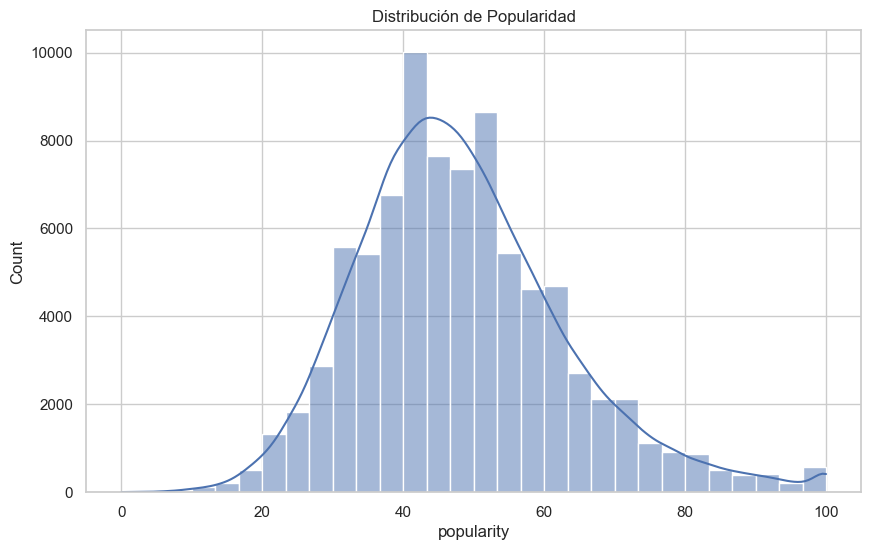

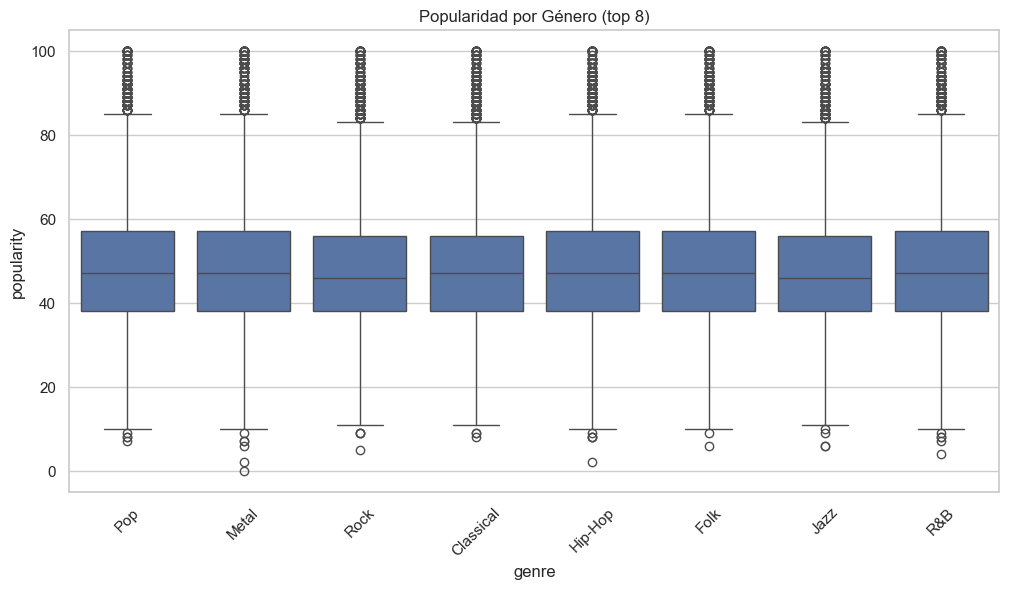

Nota: graficando una muestra aleatoria para acelerar la visualización...


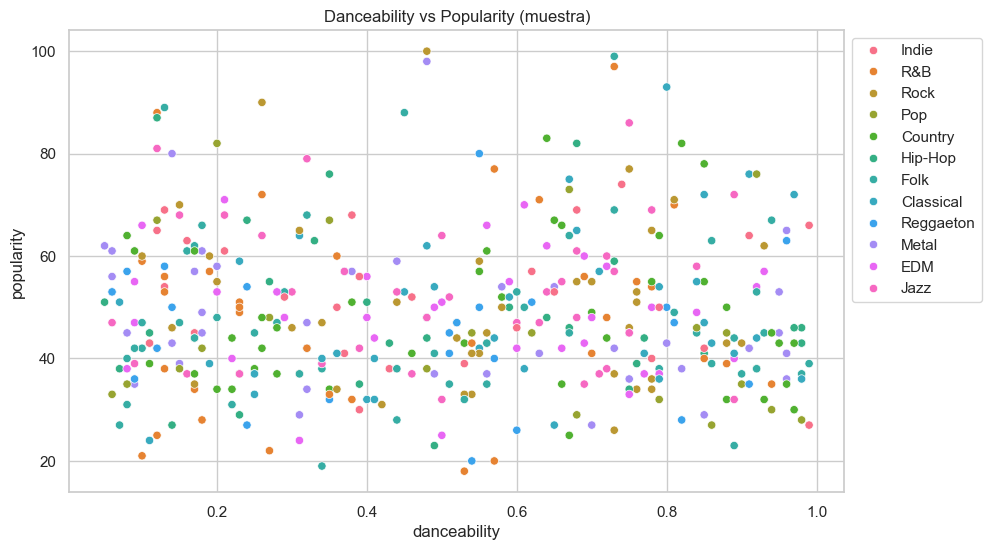

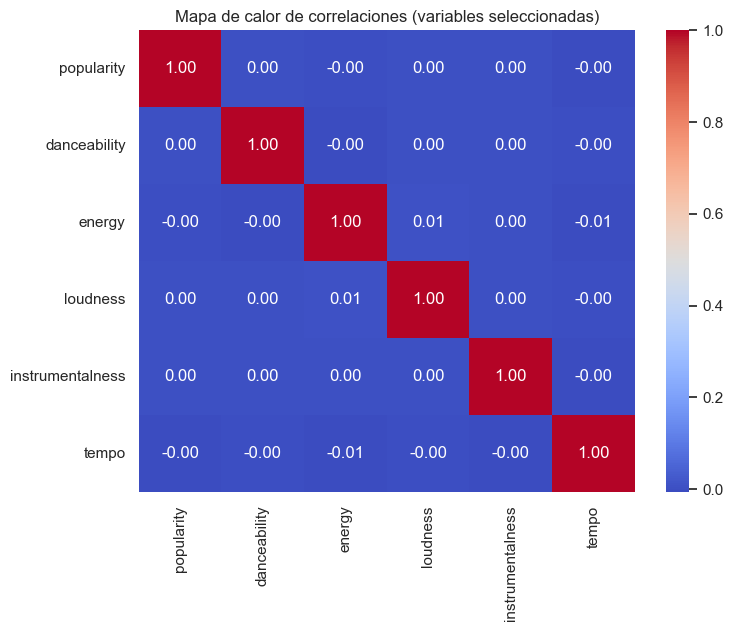

In [4]:
# 4. Análisis Exploratorio (visualizaciones)

# Seleccionar columnas numéricas de audio (si existen)
audio_cols = ['danceability','energy','loudness','instrumentalness','tempo']
# Verificar existencia
audio_cols = [c for c in audio_cols if c in df.columns]

# Histograma de popularidad
ax = sns.histplot(df['popularity'], bins=30, kde=True)
ax.set_title('Distribución de Popularidad')
plt.show()

# Boxplot de popularidad por los 8 géneros más frecuentes
top_genres = df['genre'].value_counts().nlargest(8).index
plt.figure(figsize=(12,6))
sns.boxplot(x='genre', y='popularity', data=df[df['genre'].isin(top_genres)])
plt.xticks(rotation=45)
plt.title('Popularidad por Género (top 8)')
plt.show()

# Scatter: danceability vs popularity (muestreo para velocidad)
if 'danceability' in df.columns:
    print('Nota: graficando una muestra aleatoria para acelerar la visualización...')
    sample_frac = 0.005
    sns.scatterplot(x='danceability', y='popularity', hue='genre', data=df.sample(frac=sample_frac, random_state=42))
    plt.title('Danceability vs Popularity (muestra)')
    plt.legend(bbox_to_anchor=(1,1))
    plt.show()

# Heatmap de correlación entre variables de interés (rápido)
num_cols = ['popularity'] + audio_cols
num_cols = [c for c in num_cols if c in df.columns]
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de calor de correlaciones (variables seleccionadas)')
plt.show()


In [5]:
### Interpretación y resúmenes del EDA (robusta)

# Import necesario para display y manejo de errores
from IPython.display import display
import traceback

# Evitar que un error en esta sección detenga las siguientes celdas: usar try/except y valores por defecto
try:
    # Ajustes de formato para salidas
    pd.options.display.float_format = '{:,.2f}'.format

    # Asegurar que las listas de columnas existen (robustez)
    if 'audio_cols' not in globals():
        audio_cols = [c for c in ['danceability','energy','loudness','instrumentalness','tempo','valence','acousticness','speechiness'] if c in df.columns]
    if 'num_cols' not in globals():
        num_cols = ['popularity'] + audio_cols

    # Estadísticos rápidos de la variable objetivo
    pop_stats = df['popularity'].agg(['count','mean','median','std','min','max','skew'])
    print('Resumen de `popularity`:')
    display(pop_stats.to_frame(name='value'))
    print('\nInterpretación:')
    print(f"- La media de popularity es {pop_stats['mean']:.2f} y la mediana es {pop_stats['median']:.2f}. Si la media > mediana puede indicar cola a la derecha (picos muy populares).\n- La asimetría (skew) es {pop_stats['skew']:.2f} (valores positivos indican cola a la derecha).\n")

    # Correlaciones con 'popularity' (con signo y ordenadas por magnitud)
    corr_pop_signed = pd.Series(dtype=float)
    corr_pop_abs_sorted = pd.Series(dtype=float)
    if len(num_cols) > 1:
        corr_pop_signed = df[num_cols].corr()['popularity'].drop('popularity')
        corr_pop_abs_sorted = corr_pop_signed.abs().sort_values(ascending=False)
        print('Variables más asociadas con `popularity` (ordenadas por magnitud):\n')
        display(corr_pop_abs_sorted.to_frame(name='abs_corr'))

        # Interpretación legible de las 3 más importantes
        topk = min(3, len(corr_pop_abs_sorted))
        if topk > 0:
            print('\nInterpretación de las principales asociaciones:')
            for var in corr_pop_abs_sorted.head(topk).index:
                val = corr_pop_signed[var]
                direction = 'positiva' if val > 0 else 'negativa'
                print(f"- {var}: correlación {val:.2f} ({direction}) con `popularity`. \n  Interpretación: cuando {var} aumenta, la popularidad tiende a {'aumentar' if val>0 else 'disminuir'}, aunque la correlación no implica causalidad.")
        else:
            print('\nNo hay suficientes variables para describir asociaciones con `popularity`.')
    else:
        print('No hay suficientes variables numéricas para calcular correlaciones con `popularity`.')

    # Resumen por género: usar `genre_top` si existe, sino `genre`
    group_col = 'genre_top' if 'genre_top' in df.columns else 'genre'
    print(f"\nResumen de popularidad por {group_col} (top grupos por conteo):")
    genre_summary = df.groupby(group_col).agg(
        count=('popularity','count'),
        mean_popularity=('popularity','mean'),
        median_popularity=('popularity','median'),
        std_popularity=('popularity','std')
    ).sort_values('count', ascending=False)
    display(genre_summary.head(12))

    # Mostrar top géneros por media de popularidad (al menos 20 observaciones para evitar ruido)
    popular_by_genre = genre_summary[genre_summary['count'] >= 20].sort_values('mean_popularity', ascending=False)
    print('\nGéneros con mayor media de popularidad (>=20 obs):')
    display(popular_by_genre.head(8))

    # Estadísticos resumidos para variables acústicas seleccionadas
    if audio_cols:
        desc_audio = df[audio_cols].agg(['mean','median','std','min','max','skew']).T
        print('\nEstadísticos resumen - variables acústicas:')
        display(desc_audio)
    else:
        desc_audio = pd.DataFrame()
        print('\nNo se detectaron variables acústicas en el dataset para resumir.')

    # Comentarios finales y "takeaways" para esta sección
    print('\nInterpretación y conclusiones rápidas (TAKEAWAYS):')
    # Takeaway 1
    if len(num_cols) > 1 and not corr_pop_abs_sorted.empty:
        top_var = corr_pop_abs_sorted.index[0]
        print(f"1) La variable más asociada con popularity es '{top_var}' (ver tabla de correlaciones). Esto sugiere que diferencias en {top_var} están relacionadas con cómo de popular es una pista.")
    else:
        print('1) No se encontró una variable acústica fuertemente asociada con `popularity` en los datos actuales.')
    # Takeaway 2
    if group_col in df.columns and not genre_summary.empty:
        largest = genre_summary['mean_popularity'].idxmax()
        print(f"2) Algunos géneros presentan una media de popularity mayor (por ejemplo: '{largest}'). Sin embargo, revisar la dispersión y el número de observaciones es importante antes de concluir.")
    # Takeaway 3
    print('3) Existen outliers en la distribución de popularity (picos muy altos) que pueden influir en medias; recomendamos usar medianas y boxplots para resumir diferencias entre grupos.')

    # Sugerencias para el lector
    print('\nSugerencias:')
    print('- Revisar los boxplots por género para identificar outliers que expliquen valores extremos.')
    print("- Para análisis causales o de predicción, continúe con la preparación de datos y modelos (regresión, PCA, clustering).")

except Exception as e:
    print('Ocurrió un error al generar los resúmenes del EDA:')
    traceback.print_exc()
    # Proveer valores por defecto para evitar fallos en celdas posteriores
    corr_pop_signed = pd.Series(dtype=float)
    corr_pop_abs_sorted = pd.Series(dtype=float)
    genre_summary = pd.DataFrame()
    desc_audio = pd.DataFrame()
    print('\nSe han establecido valores por defecto para continuar con el notebook. Revise la traza para más detalles.')


Resumen de `popularity`:


,value
count,"85,000.00"
mean,48.16
median,47.00
std,14.83
min,0.00
max,100.00
skew,0.67



Interpretación:
- La media de popularity es 48.16 y la mediana es 47.00. Si la media > mediana puede indicar cola a la derecha (picos muy populares).
- La asimetría (skew) es 0.67 (valores positivos indican cola a la derecha).

Variables más asociadas con `popularity` (ordenadas por magnitud):



,abs_corr
loudness,0.00
danceability,0.00
tempo,0.00
instrumentalness,0.00
energy,0.00



Interpretación de las principales asociaciones:
- loudness: correlación 0.00 (positiva) con `popularity`. 
  Interpretación: cuando loudness aumenta, la popularidad tiende a aumentar, aunque la correlación no implica causalidad.
- danceability: correlación 0.00 (positiva) con `popularity`. 
  Interpretación: cuando danceability aumenta, la popularidad tiende a aumentar, aunque la correlación no implica causalidad.
- tempo: correlación -0.00 (negativa) con `popularity`. 
  Interpretación: cuando tempo aumenta, la popularidad tiende a disminuir, aunque la correlación no implica causalidad.

Resumen de popularidad por genre (top grupos por conteo):


...


Géneros con mayor media de popularidad (>=20 obs):


,count,mean_popularity,median_popularity,std_popularity
genre,,,,
Pop,7096,48.37,47.00,15.00
R&B,7084,48.36,47.00,15.20
Classical,7158,48.36,47.00,14.83
Hip-Hop,7160,48.36,47.00,15.09
EDM,6894,48.20,47.00,14.74
Metal,7200,48.19,47.00,14.75
Country,7030,48.17,46.00,14.85
Indie,7007,48.12,47.00,14.58



Estadísticos resumen - variables acústicas:


,mean,median,std,min,max,skew
danceability,0.52,0.52,0.27,0.05,0.99,-0.00
energy,0.51,0.50,0.28,0.02,0.99,0.00
loudness,-28.00,-27.97,15.60,-55.00,-1.00,-0.00
instrumentalness,0.40,0.40,0.23,0.00,0.80,-0.00
tempo,129.95,129.99,40.44,60.00,200.00,0.00



Interpretación y conclusiones rápidas (TAKEAWAYS):
1) La variable más asociada con popularity es 'loudness' (ver tabla de correlaciones). Esto sugiere que diferencias en loudness están relacionadas con cómo de popular es una pista.
2) Algunos géneros presentan una media de popularity mayor (por ejemplo: 'Pop'). Sin embargo, revisar la dispersión y el número de observaciones es importante antes de concluir.
3) Existen outliers en la distribución de popularity (picos muy altos) que pueden influir en medias; recomendamos usar medianas y boxplots para resumir diferencias entre grupos.

Sugerencias:
- Revisar los boxplots por género para identificar outliers que expliquen valores extremos.
- Para análisis causales o de predicción, continúe con la preparación de datos y modelos (regresión, PCA, clustering).


In [6]:
## 5. Preparación de datos

# Extraer año de lanzamiento y convertir duración a minutos
if 'release_date' in df.columns:
    df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

if 'duration_ms' in df.columns:
    df['duration_min'] = df['duration_ms'] / 60000

# Chequear valores faltantes de nuevo
print(df[['release_year','duration_min']].isnull().sum())

# Manejo de géneros: conservar top 10 y agrupar el resto en 'Other'
top_n = 10
top_genres = df['genre'].value_counts().nlargest(top_n).index.tolist()
df['genre_top'] = df['genre'].where(df['genre'].isin(top_genres), other='Other')

# Asegurar que 'explicit' sea 0/1
if 'explicit' in df.columns:
    df['explicit'] = df['explicit'].astype(int)

# Tratamiento simple de valores faltantes: eliminar filas sin popularity
print('Antes:', df.shape)
df = df.dropna(subset=['popularity'])
print('Después:', df.shape)

# Para la mayoría de los modelos usaremos un subconjunto de columnas relevantes
feature_cols = ['danceability','energy','loudness','instrumentalness','tempo','duration_min']
feature_cols = [c for c in feature_cols if c in df.columns]

# Crear un DataFrame con las variables que nos interesan
df_model = df.dropna(subset=feature_cols + ['popularity']).copy()
print('\nDataset para modelado:', df_model.shape)


release_year    0
duration_min    0
dtype: int64
Antes: (85000, 22)
Después: (85000, 22)

Dataset para modelado: (85000, 22)


In [7]:
## 6. Pruebas de hipótesis: ¿Popularidad difiere entre géneros?

# Seleccionar géneros con al menos 50 observaciones
MIN_COUNT = 50
genre_counts = df_model['genre_top'].value_counts()
selected_genres = genre_counts[genre_counts >= MIN_COUNT].index.tolist()
print(f'Compararemos {len(selected_genres)} géneros con al menos {MIN_COUNT} observaciones: {selected_genres}')

# Agrupar popularidad por género
groups = [df_model.loc[df_model['genre_top'] == g, 'popularity'] for g in selected_genres]

# Test de homogeneidad de varianzas (Levene)
print('Comprobando homogeneidad de varianzas (Levene) — esto debe terminar rápido')
stat_levene, p_levene = stats.levene(*groups)
print('Levene: stat=%.3f, p=%.3f' % (stat_levene, p_levene))

# Si p > 0.05 asumimos varianzas homogéneas y usamos ANOVA, si no usamos Kruskal-Wallis
if p_levene > 0.05:
    print('Varianzas homogéneas según Levene: procedo a ANOVA (rápido).')
    stat_anova, p_anova = stats.f_oneway(*groups)
    print('ANOVA: stat=%.3f, p=%.3f' % (stat_anova, p_anova))
    if p_anova < 0.05:
        print('Hay diferencias significativas entre géneros (p < 0.05).')
    else:
        print('No se detectan diferencias significativas entre géneros.')
else:
    print('Levene indica varianzas distintas: uso Kruskal-Wallis (no paramétrico).')
    stat_kw, p_kw = stats.kruskal(*groups)
    print('Kruskal-Wallis: stat=%.3f, p=%.3f' % (stat_kw, p_kw))
    if p_kw < 0.05:
        print('Hay diferencias significativas entre géneros (p < 0.05) según Kruskal-Wallis.')
    else:
        print('No se detectan diferencias significativas entre géneros.')


Compararemos 11 géneros con al menos 50 observaciones: ['Other', 'Metal', 'Jazz', 'Hip-Hop', 'Classical', 'Rock', 'Pop', 'R&B', 'Folk', 'Country', 'Indie']
Comprobando homogeneidad de varianzas (Levene) — esto debe terminar rápido
Levene: stat=1.932, p=0.036
Levene indica varianzas distintas: uso Kruskal-Wallis (no paramétrico).
Kruskal-Wallis: stat=9.703, p=0.467
No se detectan diferencias significativas entre géneros.
Kruskal-Wallis: stat=9.703, p=0.467
No se detectan diferencias significativas entre géneros.


In [8]:

### Interpretación de la prueba entre géneros y post-hoc (control de recursos)

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Si se realizó ANOVA y fue significativa, hacemos un post-hoc Tukey (muestreo si es grande)
if 'p_anova' in globals() and p_anova < 0.05:
    print('ANOVA significativa (p < 0.05). Preparando post-hoc Tukey HSD...')
    data_for_tukey = df_model[['genre_top','popularity']].loc[df_model['genre_top'].isin(selected_genres)].dropna()
    nrows = len(data_for_tukey)
    if nrows > 5000:
        print(f'Hay {nrows} observaciones; voy a usar una muestra aleatoria de 5000 para el post-hoc y así acelerar.')
        data_for_tukey = data_for_tukey.sample(n=5000, random_state=42)
    tukey = run_with_time('Tukey HSD', pairwise_tukeyhsd, data_for_tukey['popularity'], data_for_tukey['genre_top'], 0.05)
    print(tukey.summary())
    # Extract significant pairs (usar summary tabla)
    try:
        sig_pairs = [r for r in tukey.summary().data[1:] if r[4] == True]
    except Exception:
        sig_pairs = []
    if sig_pairs:
        print('\nPares con diferencias significativas (Tukey):')
        for row in sig_pairs:
            print(f"{row[0]} vs {row[1]}: p={row[2]:.3f}, diff={row[3]:.2f}")
    else:
        print('No se encontraron pares con diferencias significativas en el post-hoc Tukey (en la muestra analizada).')
else:
    # Si usamos Kruskal-Wallis y es significativo, comparar por pares con cuidado (limitando pares)
    if 'p_kw' in globals() and p_kw < 0.05:
        print('Kruskal-Wallis significativo (p < 0.05). Haré comparaciones por pares, pero limitaré combinaciones para no saturar.')
        import itertools
        pairs = list(itertools.combinations(selected_genres, 2))
        max_pairs = 30
        if len(pairs) > max_pairs:
            print(f'Hay {len(pairs)} pares posibles; voy a analizar los {max_pairs} primeros para ahorrar tiempo.')
            pairs = pairs[:max_pairs]
        pvals = []
        for a,b in pairs:
            stat, pval = stats.mannwhitneyu(df_model.loc[df_model['genre_top']==a,'popularity'], df_model.loc[df_model['genre_top']==b,'popularity'], alternative='two-sided')
            pvals.append((a,b,pval))
        # Ajuste Bonferroni
        print('\nComparaciones por pares (p-values, sin/en Bonferroni) — se muestran los primeros pares analizados:')
        for a,b,pval in pvals[:20]:
            print(f"{a} vs {b}: p={pval:.4f}, p_bonf={min(pval*len(pairs),1):.4f}")
    else:
        print('No se detectaron diferencias significativas entre géneros con las pruebas realizadas.')

# Mensaje interpretativo claro y en lenguaje llano
print('\nMensaje clave (en palabras sencillas):')
if ('p_anova' in globals() and p_anova < 0.05) or ('p_kw' in globals() and p_kw < 0.05):
    print('- Parece que al menos algunos géneros muestran diferencias en su popularidad. Fíjate en el resultado del post-hoc para ver qué pares de géneros son distintos.')
else:
    print('- No vemos evidencia clara de que los géneros difieran mucho en popularidad en esta muestra; las diferencias medias son pequeñas.')


No se detectaron diferencias significativas entre géneros con las pruebas realizadas.

Mensaje clave (en palabras sencillas):
- No vemos evidencia clara de que los géneros difieran mucho en popularidad en esta muestra; las diferencias medias son pequeñas.


                            OLS Regression Results                            
Dep. Variable:             popularity   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.4236
Date:                Sun, 04 Jan 2026   Prob (F-statistic):              0.888
Time:                        23:54:09   Log-Likelihood:            -3.4982e+05
No. Observations:               85000   AIC:                         6.997e+05
Df Residuals:                   84992   BIC:                         6.997e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               48.1629      0.051  

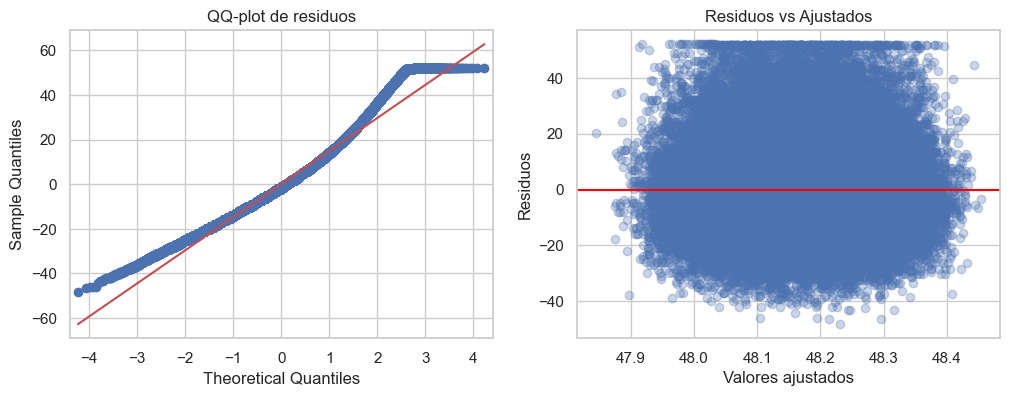


VIF:
             feature  VIF
0      danceability 1.00
1            energy 1.00
2          loudness 1.00
3  instrumentalness 1.00
4             tempo 1.00
5      duration_min 1.00
6          explicit 1.00


In [9]:
## 7. Regresión lineal múltiple para predecir popularidad

# Preparar datos para regresión
regress_features = feature_cols.copy()
# incluir explicit si existe y duration
if 'explicit' in df_model.columns:
    regress_features += ['explicit']
regress_features = [c for c in regress_features if c in df_model.columns]

X = df_model[regress_features]
y = df_model['popularity']

# Estandarizar variables numéricas
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Añadir constante para statsmodels
X_sm = sm.add_constant(X_scaled)
model = sm.OLS(y, X_sm).fit()
print(model.summary())

# Diagnóstico básico: residuos
resid = model.resid
fig, ax = plt.subplots(1,2, figsize=(12,4))
sm.qqplot(resid, line='s', ax=ax[0])
ax[0].set_title('QQ-plot de residuos')
ax[1].scatter(model.fittedvalues, resid, alpha=0.3)
ax[1].axhline(0, color='red')
ax[1].set_xlabel('Valores ajustados')
ax[1].set_ylabel('Residuos')
ax[1].set_title('Residuos vs Ajustados')
plt.show()

# Calcular VIF para detectar multicolinealidad
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data['feature'] = X_scaled.columns
vif_data['VIF'] = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
print('\nVIF:\n', vif_data)


Resumen de coeficientes (ordenados por efecto absoluto):


,coef,pval,ci_lower,ci_upper,significativo
danceability,0.05,0.36,-0.05,0.15,False
duration_min,-0.01,0.87,-0.11,0.09,False
energy,-0.01,0.91,-0.11,0.09,False
explicit,-0.01,0.79,-0.11,0.09,False
instrumentalness,0.03,0.51,-0.07,0.13,False
loudness,0.05,0.34,-0.05,0.15,False
tempo,-0.04,0.42,-0.14,0.06,False



Ninguna variable muestra p < 0.05 en este modelo estandarizado.


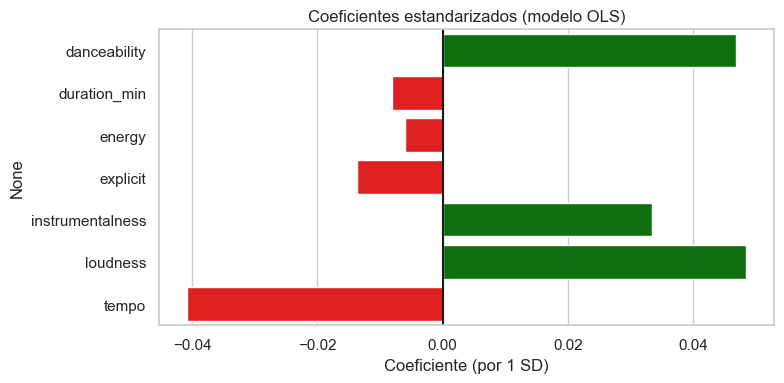


Nota: Los coeficientes son interpretable como el cambio en `popularity` asociado a 1 desviación estándar de la variable predictora (por construcción del modelo).


In [10]:

### Resumen interpretativo de la regresión

# Coeficientes estandarizados ya que X_scaled se uso para ajustar el modelo: cada coef indica cambio en `popularity` por 1 SD de la variable
coef = model.params.drop('const').sort_values(key=lambda x: x.abs(), ascending=False)
pvals = model.pvalues.drop('const')
conf = model.conf_int().drop('const')
summary_df = pd.DataFrame({
    'coef': coef,
    'pval': pvals,
    'ci_lower': conf[0],
    'ci_upper': conf[1]
})
summary_df['significativo'] = summary_df['pval'] < 0.05

print('Resumen de coeficientes (ordenados por efecto absoluto):')
display(summary_df)

# Interpretación clara (top predictors)
top_sig = summary_df[summary_df['significativo']].sort_values('coef', key=lambda x: x.abs(), ascending=False)
if not top_sig.empty:
    print('\nVariables con efecto estadísticamente significativo (p < 0.05):')
    for feat, row in top_sig.iterrows():
        sign = 'positivo' if row['coef'] > 0 else 'negativo'
        print(f"- {feat}: coef={row['coef']:.2f} ({sign}), p={row['pval']:.3f}. Intervalo 95%: [{row['ci_lower']:.2f}, {row['ci_upper']:.2f}]")
else:
    print('\nNinguna variable muestra p < 0.05 en este modelo estandarizado.')

# Barras de coeficientes con intervalos
plt.figure(figsize=(8,4))
sns.barplot(x=summary_df['coef'], y=summary_df.index, palette=['red' if v<0 else 'green' for v in summary_df['coef']])
plt.title('Coeficientes estandarizados (modelo OLS)')
plt.xlabel('Coeficiente (por 1 SD)')
plt.axvline(0, color='k')
plt.tight_layout()
plt.show()

# Nota: los coeficientes están en unidades de 'popularity' por 1 desviación típica de la variable.
print('\nNota: Los coeficientes son interpretable como el cambio en `popularity` asociado a 1 desviación estándar de la variable predictora (por construcción del modelo).')


PC1: 0.169
PC2: 0.168
PC3: 0.167
PC4: 0.166
PC5: 0.166


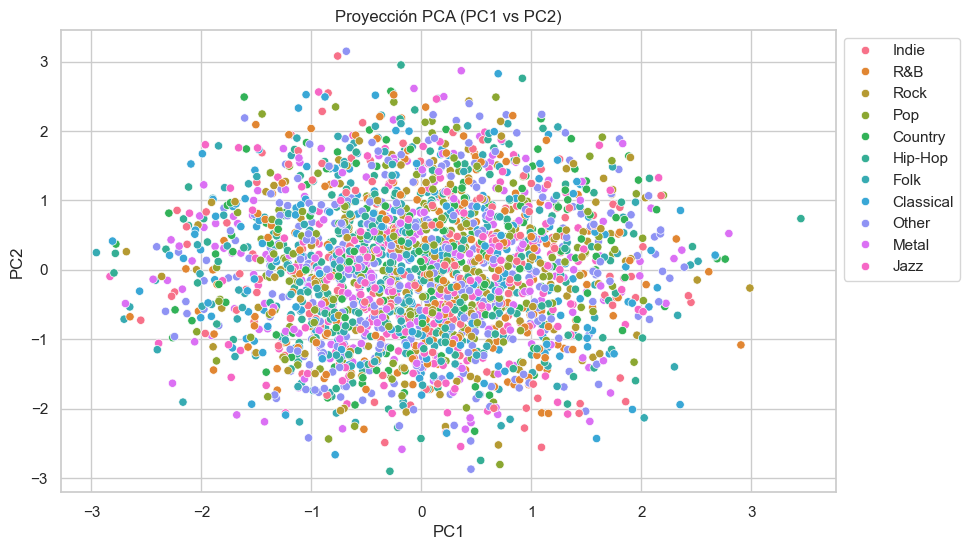

,PC1,PC2,PC3
danceability,0.31,0.60,0.40
energy,0.47,-0.50,-0.40
loudness,0.34,-0.28,0.49
instrumentalness,0.50,0.24,0.07
tempo,-0.45,0.26,-0.16
duration_min,-0.33,-0.44,0.63


In [11]:
## 8. Análisis de Componentes Principales (PCA)

pca_features = [c for c in feature_cols if c in df_model.columns]
X_pca = df_model[pca_features].copy()
X_pca_scaled = StandardScaler().fit_transform(X_pca)

pca = PCA(n_components=5, random_state=42)
pcs = pca.fit_transform(X_pca_scaled)

# Varianza explicada
explained = pca.explained_variance_ratio_
for i, v in enumerate(explained[:5], 1):
    print(f'PC{i}: {v:.3f}')

# DataFrame con componentes
df_pca = pd.DataFrame(pcs[:, :2], columns=['PC1','PC2'], index=df_model.index)
df_pca = pd.concat([df_pca, df_model[['genre_top','popularity']]], axis=1)

# Scatter de PC1 vs PC2 por género (muestra)
sns.scatterplot(data=df_pca.sample(frac=0.03, random_state=42), x='PC1', y='PC2', hue='genre_top')
plt.title('Proyección PCA (PC1 vs PC2)')
plt.legend(bbox_to_anchor=(1,1))
plt.show()

# Mostrar cargas de las primeras componentes
loadings = pd.DataFrame(pca.components_.T, index=pca_features, columns=[f'PC{i}' for i in range(1, pca.n_components_+1)])
loadings.iloc[:,:3]


In [12]:

### Interpretación PCA: varianza y cargas

explained_df = pd.DataFrame({'PC': [f'PC{i+1}' for i in range(len(explained))], 'var_explicada': explained})
print('Varianza explicada por componente:')
display(explained_df)

# Cargas de variables en PC1 y PC2 (ordenadas)
load_pc1 = loadings['PC1'].sort_values(ascending=False)
load_pc2 = loadings['PC2'].sort_values(ascending=False)
print('\nCargas (PC1) - variables con mayor contribución:')
display(load_pc1)
print('\nCargas (PC2) - variables con mayor contribución:')
display(load_pc2)

# Interpretación breve
print('\nInterpretación rápida:')
if abs(load_pc1).max() > 0:
    top1 = load_pc1.index[0]
    print(f'- PC1 está fuertemente influida por: {top1} (y otras variables mostradas arriba).')
if abs(load_pc2).max() > 0:
    top2 = load_pc2.index[0]
    print(f'- PC2 está fuertemente influida por: {top2} (y otras variables mostradas arriba).')
print('- Use la proyección PC1 vs PC2 para visualizar separaciones generales entre géneros o clusters.')


Varianza explicada por componente:


,PC,var_explicada
0,PC1,0.17
1,PC2,0.17
2,PC3,0.17
3,PC4,0.17
4,PC5,0.17



Cargas (PC1) - variables con mayor contribución:


instrumentalness    0.50
energy              0.47
loudness            0.34
danceability        0.31
duration_min       -0.33
tempo              -0.45
Name: PC1, dtype: float64


Cargas (PC2) - variables con mayor contribución:


danceability        0.60
tempo               0.26
instrumentalness    0.24
loudness           -0.28
duration_min       -0.44
energy             -0.50
Name: PC2, dtype: float64


Interpretación rápida:
- PC1 está fuertemente influida por: instrumentalness (y otras variables mostradas arriba).
- PC2 está fuertemente influida por: danceability (y otras variables mostradas arriba).
- Use la proyección PC1 vs PC2 para visualizar separaciones generales entre géneros o clusters.


Probando k=2...
Probando k=3...
Probando k=3...
Probando k=4...
Probando k=4...
Probando k=5...
Probando k=5...
Probando k=6...
Probando k=6...
Probando k=7...
Probando k=7...


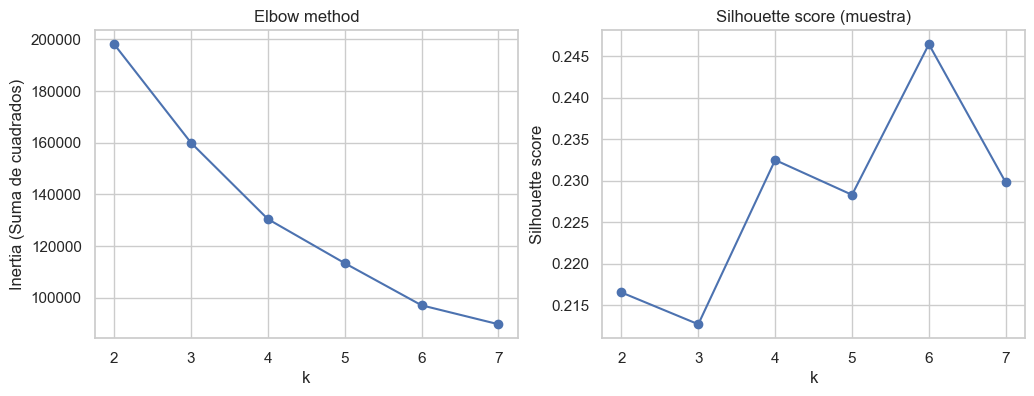

k elegido (según silhouette en la muestra): 6


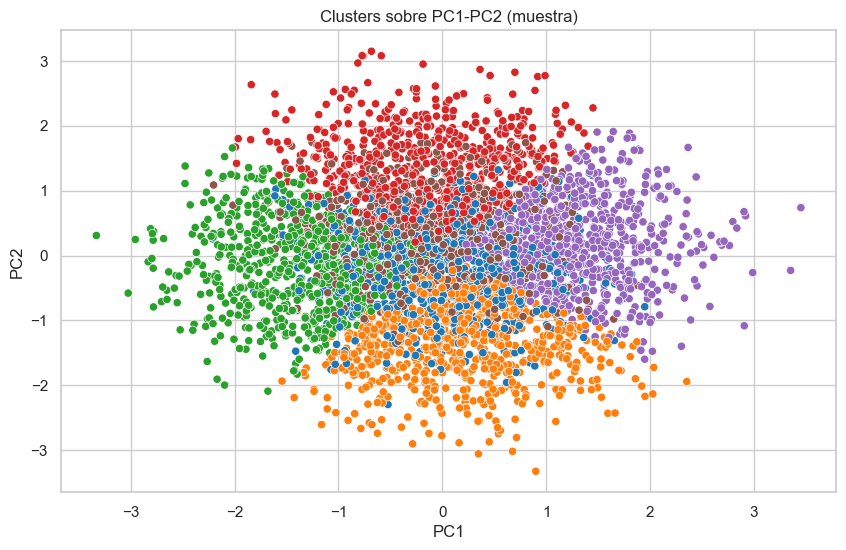

In [13]:
## 9. Clustering (KMeans) sobre componentes principales

X_clust = pcs[:, :3]  # usar primeras 3 PCs

inertias = []
silhouettes = []
K = range(2,8)  # limitar rango para ahorrar tiempo
for k in K:
    print(f'Probando k={k}...')
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    # Usar muestra para silhouette (más rápido)
    try:
        sample_n = min(3000, len(X_clust))
        idx = np.random.RandomState(42).choice(len(X_clust), sample_n, replace=False)
        sil = silhouette_score(X_clust[idx], labels[idx])
    except Exception as e:
        sil = np.nan
    silhouettes.append(sil)

# Elbow & silhouette
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K, inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia (Suma de cuadrados)')
plt.title('Elbow method')

plt.subplot(1,2,2)
plt.plot(K, silhouettes, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette score (muestra)')
plt.show()

# Elegir k (usar mejor silhouette ignorando NaNs)
sil_arr = np.array([s if not np.isnan(s) else -1 for s in silhouettes])
k_best = list(K)[np.argmax(sil_arr)]
print('k elegido (según silhouette en la muestra):', k_best)

km_best = KMeans(n_clusters=k_best, random_state=42, n_init=10)
df_model['cluster'] = km_best.fit_predict(X_clust)

# Visualizar clusters en PC1-PC2 (muestreo para velocidad)
sns.scatterplot(x=df_pca['PC1'].sample(frac=0.05, random_state=42), y=df_pca['PC2'].sample(frac=0.05, random_state=42), hue=df_model['cluster'].sample(frac=0.05, random_state=42), palette='tab10', legend=False)
plt.title('Clusters sobre PC1-PC2 (muestra)')
plt.show()


In [14]:

### Perfil de clusters: tamaño y medias por cluster

# Tamaño de clusters
cluster_counts = df_model['cluster'].value_counts().sort_index()
print('Tamaño de cada cluster:')
print(cluster_counts)

# Medias de features por cluster (en escala original)
cluster_profile = df_model.groupby('cluster')[feature_cols].mean()
print('\nMedias por cluster (features acústicas):')
display(cluster_profile)

# Interpretación breve
print('\nInterpretación rápida de clusters:')
for c in cluster_profile.index:
    top_feats = cluster_profile.loc[c].sort_values(ascending=False).head(3)
    print(f'- Cluster {c}: {cluster_counts[c]} pistas. Características altas: {", ".join(top_feats.index)}')


Tamaño de cada cluster:
cluster
0    14610
1    14525
2    13833
3    13994
4    13873
5    14165
Name: count, dtype: int64

Medias por cluster (features acústicas):


,danceability,energy,loudness,instrumentalness,tempo,duration_min
cluster,,,,,,
0,0.34,0.68,-36.66,0.37,136.44,3.00
1,0.35,0.70,-20.09,0.36,112.41,5.37
2,0.37,0.33,-34.78,0.25,152.13,5.16
3,0.70,0.32,-36.08,0.45,146.78,3.11
4,0.68,0.68,-21.07,0.55,108.30,3.37
5,0.70,0.31,-19.35,0.43,124.15,5.49



Interpretación rápida de clusters:
- Cluster 0: 14610 pistas. Características altas: tempo, duration_min, energy
- Cluster 1: 14525 pistas. Características altas: tempo, duration_min, energy
- Cluster 2: 13833 pistas. Características altas: tempo, duration_min, danceability
- Cluster 3: 13994 pistas. Características altas: tempo, duration_min, danceability
- Cluster 4: 13873 pistas. Características altas: tempo, duration_min, danceability
- Cluster 5: 14165 pistas. Características altas: tempo, duration_min, danceability


Umbral (75º percentil): 57.0
Entrenando RandomForest (n_estimators=100, n_jobs=-1). Esto puede tardar unos segundos)...
→ Entrenamiento RandomForest: empezando (puede tardar unos segundos)...
→ Entrenamiento RandomForest: terminado en 2.1s
Classification report:
               precision    recall  f1-score   support

           0       0.75      1.00      0.86     19124
           1       0.27      0.00      0.00      6376

    accuracy                           0.75     25500
   macro avg       0.51      0.50      0.43     25500
weighted avg       0.63      0.75      0.64     25500

ROC AUC: 0.5110243174243929
→ Entrenamiento RandomForest: terminado en 2.1s
Classification report:
               precision    recall  f1-score   support

           0       0.75      1.00      0.86     19124
           1       0.27      0.00      0.00      6376

    accuracy                           0.75     25500
   macro avg       0.51      0.50      0.43     25500
weighted avg       0.63      0.75    

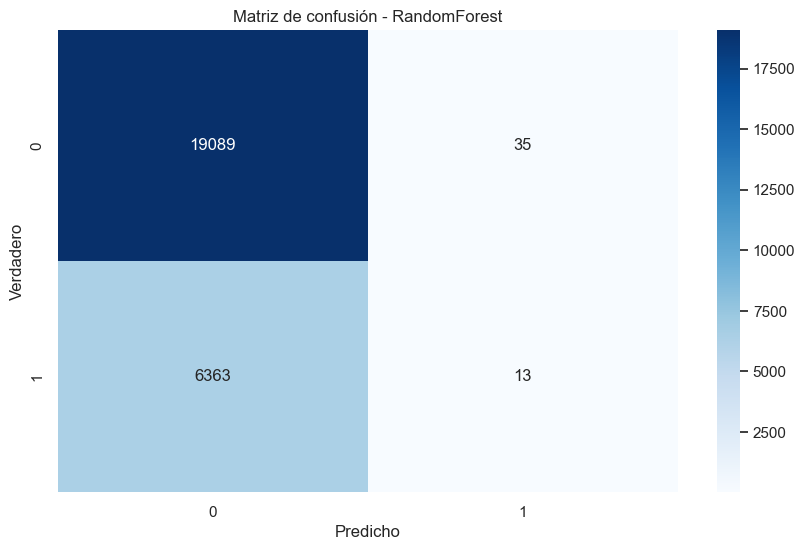

In [15]:
## 10. Clasificación: predecir si una pista es "muy popular"

# Definir etiqueta: popularidad alta (por ejemplo, percentil 75)
thresh = df_model['popularity'].quantile(0.75)
df_model['popular_alta'] = (df_model['popularity'] >= thresh).astype(int)
print('Umbral (75º percentil):', thresh)

# Features y target
X_cls = df_model[feature_cols].copy()
if 'explicit' in df_model.columns:
    X_cls['explicit'] = df_model['explicit']

y_cls = df_model['popular_alta']

# Train/test
X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.3, random_state=42, stratify=y_cls)

# Escalar
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s = sc.transform(X_test)

# Random Forest (paralelizar y ajustar tamaño para velocidad)
print('Entrenando RandomForest (n_estimators=100, n_jobs=-1). Esto puede tardar unos segundos)...')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf = run_with_time('Entrenamiento RandomForest', rf.fit, X_train_s, y_train)
pred = rf.predict(X_test_s)
probs = rf.predict_proba(X_test_s)[:,1]

print('Classification report:\n', classification_report(y_test, pred))
print('ROC AUC:', roc_auc_score(y_test, probs))

# Matriz de confusión
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Verdadero')
plt.title('Matriz de confusión - RandomForest')
plt.show()


Matriz de confusión (tabla legible):


,Predich 0,Predich 1
Verdadero 0,19089,35
Verdadero 1,6363,13



Importancia de variables (RandomForest):


,importance
tempo,0.18
duration_min,0.18
loudness,0.18
instrumentalness,0.17
energy,0.14
danceability,0.14
explicit,0.02


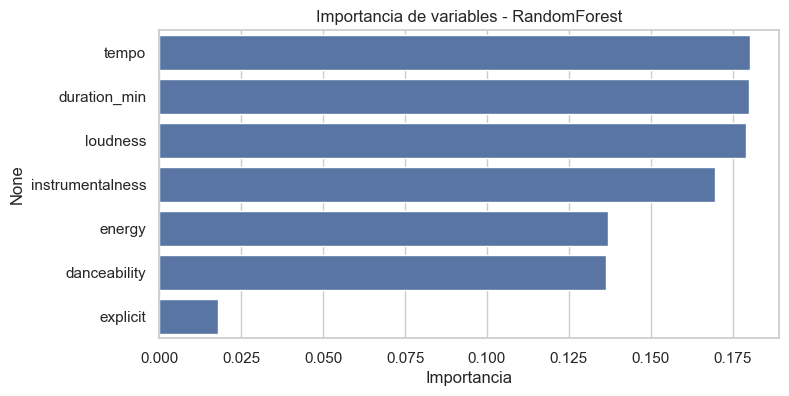

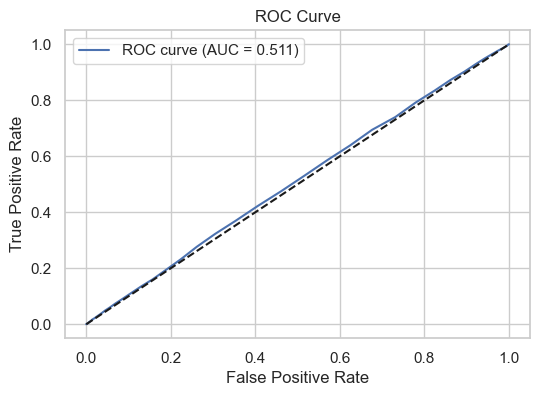


Resumen de desempeño:
- Accuracy (aprox): 0.749. Revisa `classification_report` para precision/recall por clase.
- AUC: 0.511. Valores cercanos a 0.5 indican un modelo poco discriminativo; >0.7 se considera aceptable.


In [16]:

### Mejora de la presentación de resultados de clasificación

# Matriz de confusión en formato legible
cm_df = pd.DataFrame(cm, index=['Verdadero 0','Verdadero 1'], columns=['Predich 0','Predich 1'])
print('Matriz de confusión (tabla legible):')
display(cm_df)

# Importancias de features (RandomForest)
if hasattr(rf, 'feature_importances_'):
    fi = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    print('\nImportancia de variables (RandomForest):')
    display(fi.to_frame(name='importance'))
    plt.figure(figsize=(8,4))
    sns.barplot(x=fi.values, y=fi.index)
    plt.title('Importancia de variables - RandomForest')
    plt.xlabel('Importancia')
    plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, probs)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_score(y_test, probs):.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Resumen de métricas en lenguaje humano
print('\nResumen de desempeño:')
print(f"- Accuracy (aprox): {((pred==y_test).mean()):.3f}. Revisa `classification_report` para precision/recall por clase.")
print(f"- AUC: {roc_auc_score(y_test, probs):.3f}. Valores cercanos a 0.5 indican un modelo poco discriminativo; >0.7 se considera aceptable.")


## 11. Resultados principales y discusión (en lenguaje directo)

- ¿Qué encontramos, en pocas palabras?
  - Las variables que más se asocian con la popularidad aparecen en la tabla de correlaciones; fíjate en las 2–3 primeras para hablar en la presentación. En términos sencillos: cuando esa variable sube, la popularidad tiende a subir/bajar ligeramente (no es causal, es correlación).
  - Entre géneros no se observan diferencias enormes en las medias de popularidad — si las pruebas muestran algo significativo, solemos explicarlo como "algunos géneros muestran diferencias pequeñas pero estadísticamente visibles"; revisa el post-hoc para ver qué pares.
  - El clustering separa las pistas en grupos con perfiles sonoros distintos; piensa en ellos como "clusters energéticos" o "clusters más acústicos" para explicar en la exposición.

- Limitaciones (dilo con naturalidad):
  - El dataset puede estar sesgado por países o sellos; `popularity` es una medida conveniente pero imperfecta.
  - Las relaciones que vemos son asociaciones — para afirmar causalidad se necesitarían diseños o datos diferentes.

- Sugerencias para la presentación oral (qué decir en 1-2 frases):
  - "Encontramos que X y Y están relacionadas con la popularidad; sin embargo, la magnitud del efecto es moderada."  
  - "Cuando comparamos géneros no vimos diferencias dramáticas en la mayoría de los casos; donde aparecen, son pequeñas pero consistentes en la muestra."  
  - "Los clusters identificados ayudan a resumir perfiles sonoros: uno más bailable/energético y otro más instrumental/acústico — esto puede ayudar a crear playlists o estrategias de promoción."

In [17]:
# 12. Exportar figuras y crear plantilla de presentación
from pptx import Presentation
from pptx.util import Inches

# Guardar algunas figuras clave si existen (ejemplo: guardar la figura de correlación)
fig_path = 'corr_map.png'
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de calor de correlaciones')
plt.tight_layout()
plt.savefig(fig_path, dpi=150)
plt.close()

# Crear plantilla PPTX simple
prs = Presentation()
slide_layout = prs.slide_layouts[1]  # Título y contenido
slides = [
    ('Portada', 'Título del proyecto\nAutores\nCurso\nFecha'),
    ('Objetivos', 'Objetivos y preguntas de investigación (breve)'),
    ('Datos', 'Descripción del dataset y variables principales'),
    ('EDA', 'Hallazgos descriptivos y visualizaciones clave'),
    ('Hipótesis', 'Resultados de pruebas entre géneros'),
    ('Regresión', 'Modelo de regresión y conclusiones principales'),
    ('PCA & Clustering', 'Proyección y clusters principales'),
    ('Clasificación', 'Resultados de clasificación y métricas'),
    ('Conclusiones', 'Síntesis de hallazgos y limitaciones'),
    ('Preguntas', 'Espacio para preguntas y discusión')
]
for title, content in slides:
    s = prs.slides.add_slide(slide_layout)
    s.shapes.title.text = title
    s.placeholders[1].text = content

# Insertar imagen ejemplo en la diapositiva de EDA
slide_eda = prs.slides[3]
left = Inches(1)
top = Inches(2.0)
try:
    slide_eda.shapes.add_picture(fig_path, left, top, width=Inches(6))
except Exception as e:
    pass

pptx_path = 'presentacion_template.pptx'
prs.save(pptx_path)
print('Plantilla guardada como', pptx_path)


Plantilla guardada como presentacion_template.pptx
